In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sn
import numpy as np


from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score

import sys; sys.path.insert(0, "../src")
from preprocessing import preparer
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler



# Partie A : Audit et nettoyage

In [74]:
df = pd.read_csv("../data/credits_microfinance.csv")
print(f"\n shape : {df.shape} ")
print(f"\n columns : {df.columns.to_list() } ")
print(f"Manquants : {df.isnull().sum().sum()} valeurs / {df.isnull().mean().mean()*100:.1f}% du total")
print(f"Types     : \n{df.dtypes.value_counts()}")
print(f"info : {df.info()}")
print("\n description :", df.describe())


 shape : (9255, 29) 

 columns : ['id_client', 'date_octroi', 'age', 'sexe', 'situation_matrimoniale', 'nb_personnes_charge', 'niveau_education', 'zone_habitation', 'secteur_activite', 'anciennete_activite_mois', 'revenu_mensuel_fcfa', 'charges_mensuelles_fcfa', 'possede_compte_epargne', 'montant_epargne_fcfa', 'montant_credit_fcfa', 'duree_credit_mois', 'taux_interet_annuel', 'objet_credit', 'type_garantie', 'membre_groupe_solidaire', 'nb_credits_anterieurs', 'nb_retards_anterieurs', 'score_mobile_money', 'nb_transactions_mm_mois', 'distance_agence_km', 'agent_credit', 'nb_relances_recouvrement', 'statut_dossier', 'defaut_paiement'] 
Manquants : 3307 valeurs / 1.2% du total
Types     : 
object     11
int64       9
float64     9
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_client   

## A1 Audit des valeurs manquantes

**Question :** les manquants sont-ils aléatoires (MCAR) ou liés à un profil de client
(MAR / MNAR) ? La réponse conditionne la stratégie d'imputation de la partie D.

Méthode : pour chaque colonne trouée, on construit un drapeau `manquant` et on teste
l'indépendance entre ce drapeau et toutes les autres variables  χ² pour les
catégorielles, Mann-Whitney pour les numériques  puis contre la cible `defaut_paiement`.


In [75]:
tableau = pd.DataFrame({
    "n_manquants": df.isna().sum(),
    "taux_%": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
tableau = tableau[tableau["n_manquants"] > 0].sort_values("taux_%", ascending=False)

print(f"Cellules vides   : {df.isna().sum().sum() / df.size * 100:.2f} % du tableau")
print(f"Lignes complètes : {df.notna().all(axis=1).mean()*100:.1f} %  "
      f"(supprimer les lignes trouées coûterait {(1-df.notna().all(axis=1).mean())*100:.0f} % du jeu)")
display(tableau)

Cellules vides   : 1.23 % du tableau
Lignes complètes : 68.6 %  (supprimer les lignes trouées coûterait 31 % du jeu)


,n_manquants,taux_%,dtype
score_mobile_money,1183,12.78,float64
montant_epargne_fcfa,874,9.44,float64
revenu_mensuel_fcfa,563,6.08,float64
anciennete_activite_mois,343,3.71,float64
niveau_education,204,2.20,object
nb_personnes_charge,140,1.51,float64


fonction de diagnostic

In [76]:
from scipy.stats import chi2_contingency, mannwhitneyu

COLS_CAT = ["zone_habitation", "niveau_education", "secteur_activite", "sexe",
            "situation_matrimoniale", "type_garantie", "objet_credit"]
COLS_NUM = ["age", "revenu_mensuel_fcfa", "charges_mensuelles_fcfa", "montant_credit_fcfa",
            "duree_credit_mois", "distance_agence_km", "nb_transactions_mm_mois",
            "nb_credits_anterieurs", "anciennete_activite_mois"]


def diagnostic_manquants(df, col, cols_cat=COLS_CAT, cols_num=COLS_NUM, alpha=0.05):
    """Teste si l'absence de `col` est liée au profil du client.

    Catégorielles -> chi2 d'indépendance.
    Numériques    -> Mann-Whitney (test de rang : robuste aux sentinelles -999 / 9999
                     et aux erreurs d'unité encore présentes à ce stade).
    Retourne le tableau des p-values, avec correction de Bonferroni.
    """
    mask = df[col].isna()
    print("=" * 78)
    print(f" {col} — {mask.sum()} manquants ({mask.mean()*100:.1f} %)")
    print("=" * 78)

    lignes = []
    for c in cols_cat:
        if c == col:
            continue
        tab = pd.crosstab(df[c], mask)
        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue
        lignes.append({"variable": c, "type": "cat", "p_value": chi2_contingency(tab)[1]})

    for c in cols_num:
        if c == col:
            continue
        a = df.loc[~mask, c].dropna()
        b = df.loc[mask, c].dropna()
        if len(b) < 10:
            continue
        lignes.append({"variable": c, "type": "num", "p_value": mannwhitneyu(a, b).pvalue})

    res = pd.DataFrame(lignes).sort_values("p_value").reset_index(drop=True)
    n_tests = len(res)
    seuil_bonf = alpha / n_tests                      # correction pour tests multiples
    res["p_value"] = res["p_value"].round(4)
    res["brut"] = np.where(res["p_value"] < alpha, "LIE", "indep.")
    res["corrige"] = np.where(res["p_value"] < seuil_bonf, "LIE", "indep.")
    print(f"{n_tests} tests  seuil brut {alpha}, seuil Bonferroni {seuil_bonf:.4f}")
    print(res.to_string(index=False))

    med = df.groupby(mask)[[c for c in cols_num if c != col]].median().T
    med.columns = ["complet", "manquant"]
    med["ecart_%"] = ((med["manquant"] / med["complet"] - 1) * 100).round(1)
    print("\nMédianes comparées :")
    print(med.round(1).to_string())

    cible = df.groupby(mask)["defaut_paiement"].agg(["count", "mean"])
    cible["mean"] = (cible["mean"] * 100).round(1)
    cible.index = ["complet", "manquant"]
    p_cible = chi2_contingency(pd.crosstab(df["defaut_paiement"], mask))[1]
    print(f"\nTaux de défaut (%) :\n{cible.to_string()}")
    print(f"p = {p_cible:.4f} -> l'absence est "
          f"{'INFORMATIVE' if p_cible < alpha else 'non informative'} sur la cible\n")
    return res


In [77]:
resultats = {}
for col in tableau.index:
    resultats[col] = diagnostic_manquants(df, col)

 score_mobile_money — 1183 manquants (12.8 %)
16 tests  seuil brut 0.05, seuil Bonferroni 0.0031
                variable type  p_value   brut corrige
           type_garantie  cat   0.0580 indep.  indep.
 charges_mensuelles_fcfa  num   0.0945 indep.  indep.
        niveau_education  cat   0.0949 indep.  indep.
  situation_matrimoniale  cat   0.1283 indep.  indep.
anciennete_activite_mois  num   0.1767 indep.  indep.
     montant_credit_fcfa  num   0.2751 indep.  indep.
       duree_credit_mois  num   0.2831 indep.  indep.
      distance_agence_km  num   0.3394 indep.  indep.
     revenu_mensuel_fcfa  num   0.4538 indep.  indep.
                    sexe  cat   0.4858 indep.  indep.
   nb_credits_anterieurs  num   0.6502 indep.  indep.
                     age  num   0.7150 indep.  indep.
            objet_credit  cat   0.8412 indep.  indep.
         zone_habitation  cat   0.8444 indep.  indep.
 nb_transactions_mm_mois  num   0.8972 indep.  indep.
        secteur_activite  cat   0.9440 

In [78]:
print("Le manque est-il lié à la détention d'un compte ?")
display(pd.crosstab(df["possede_compte_epargne"], df["montant_epargne_fcfa"].isna(),
                    normalize="index").round(3))

print("\nQuelle valeur prend l'épargne selon la détention d'un compte ?")
display(df.groupby("possede_compte_epargne")["montant_epargne_fcfa"]
          .agg(["count", "min", "median", "max"]))

co = df[tableau.index].isna().astype(int).corr().round(3)
display(co)

Le manque est-il lié à la détention d'un compte ?


montant_epargne_fcfa,False,True
possede_compte_epargne,,
0,0.902,0.098
1,0.912,0.088



Quelle valeur prend l'épargne selon la détention d'un compte ?


,count,min,median,max
possede_compte_epargne,,,,
0,5286,0.0,0.0,0.0
1,3095,1000.0,23700.0,445300.0


,score_mobile_money,montant_epargne_fcfa,revenu_mensuel_fcfa,anciennete_activite_mois,niveau_education,nb_personnes_charge
score_mobile_money,1.000,0.006,-0.008,-0.012,0.002,0.008
montant_epargne_fcfa,0.006,1.000,-0.000,-0.011,0.004,-0.001
revenu_mensuel_fcfa,-0.008,-0.000,1.000,-0.002,-0.014,0.002
anciennete_activite_mois,-0.012,-0.011,-0.002,1.000,0.013,-0.001
niveau_education,0.002,0.004,-0.014,0.013,1.000,-0.013
nb_personnes_charge,0.008,-0.001,0.002,-0.001,-0.013,1.000


### A1  Conclusion

68,6 % des lignes seulement sont complètes : supprimer les lignes trouées coûterait
31 % du jeu. L'imputation est donc obligatoire  reste à savoir laquelle.

**~96 tests d'indépendance ont été menés.** Cinq ressortent significatifs au seuil brut
de 5 % (`sexe` p=0,040 ; `anciennete_activite_mois` p=0,031 ; `distance_agence_km`
p=0,042 ; `nb_transactions_mm_mois` p=0,044 ; `situation_matrimoniale` p=0,033), soit
exactement le nombre de faux positifs attendus par le hasard. **Aucun ne survit à la
correction de Bonferroni** (seuil 0,003). Il n'existe donc aucun lien démontrable entre
l'absence d'une valeur et le profil du client.

| Colonne | Taux | Nature | Preuve mesurée | Décision d'imputation |
|---|---|---|---|---|
| `score_mobile_money` | 12,8 % | MCAR | 16 tests, aucun significatif après correction ; médianes identiques (revenu 79 100 vs 77 600, âge 38 vs 38) ; défaut 15,3 % vs 17,2 %, p=0,113 | médiane, **+ indicateur binaire à tester en C** |
| `montant_epargne_fcfa` | 9,4 % | MCAR pour le manque, **valeur déductible** | trous uniformes (9,8 % / 8,8 %) mais épargne = 0 sur 5 286/5 286 lignes sans compte | **0 si pas de compte, médiane du groupe (23 700) sinon** |
| `revenu_mensuel_fcfa` | 6,1 % | MCAR | défaut 15,6 % vs 14,6 %, p=0,541 — écart en sens *inverse* de l'hypothèse MNAR | médiane, apprise dans le pipeline |
| `anciennete_activite_mois` | 3,7 % | MCAR | défaut 15,6 % vs 15,2 %, p=0,895 | médiane |
| `niveau_education` | 2,2 % | MCAR | défaut 15,6 % vs 15,7 %, p=1,000 | modalité la plus fréquente |
| `nb_personnes_charge` | 1,5 % | MCAR | défaut 15,5 % vs 20,7 %, p=0,115 (n=140, non significatif) | médiane |

Les indicateurs d'absence sont par ailleurs **non corrélés entre eux** (|r| < 0,02) :
aucune cause commune de type formulaire tronqué ou agent défaillant.

**Conclusion.** Contrairement à ce que l'intitulé du TP suggérait, les clients sans score
mobile money ne forment aucun profil identifiable : ils ne sont ni plus ruraux
(34,0 % vs 32,7 %), ni moins éduqués, ni plus pauvres. Le mécanisme est MCAR, ce qui
autorise une imputation simple **sans risque de biais**   à condition qu'elle soit
apprise dans le pipeline (partie D2) et non sur le jeu complet.

Deux réserves consignées :
1. Ce diagnostic utilise les catégories non harmonisées (`Rurale` / `RURALE` comptent
   pour deux modalités), ce qui gonfle les degrés de liberté du χ². **À relancer après A4.**
2. Les deux seuls écarts non négligeables sur la cible   `score_mobile_money`
   (17,2 % vs 15,3 %) et `nb_personnes_charge` (20,7 % vs 15,5 %)   sont statistiquement
   non significatifs mais suffisamment marqués pour justifier de tester des indicateurs
   binaires d'absence en partie C, avec/sans, à modèle égal.


# A2. Détection de doublons et traitement

In [79]:
n_doublons = df.duplicated().sum()
print(f"Doublons : {n_doublons}  " )

n_doublons_id = df["id_client"].duplicated().sum()
print(f"Doublons sur id client : {n_doublons_id}  " )

doublons = df[df.duplicated(keep=False)].sort_values("id_client")
print(f"Lignes impliquées : {len(doublons)}")
display(doublons.head(6))


Doublons : 52  
Doublons sur id client : 55  
Lignes impliquées : 104


,id_client,date_octroi,age,sexe,situation_matrimoniale,nb_personnes_charge,niveau_education,zone_habitation,secteur_activite,anciennete_activite_mois,...,membre_groupe_solidaire,nb_credits_anterieurs,nb_retards_anterieurs,score_mobile_money,nb_transactions_mm_mois,distance_agence_km,agent_credit,nb_relances_recouvrement,statut_dossier,defaut_paiement
1275,CLI-000233,2021-07-30,56,F,Divorce,0.0,Superieur,URBAINE,Agriculture,104.0,...,1,3,0,76.6,22,4.0,AG-013,0,En cours,0
8287,CLI-000233,2021-07-30,56,F,Divorce,0.0,Superieur,URBAINE,Agriculture,104.0,...,1,3,0,76.6,22,4.0,AG-013,0,En cours,0
6459,CLI-000277,2022-08-31,28,M,Celibataire,2.0,Secondaire,Semi-urbaine,Agriculture,58.0,...,0,0,0,37.9,7,3.3,AG-015,0,Solde,0
8946,CLI-000277,2022-08-31,28,M,Celibataire,2.0,Secondaire,Semi-urbaine,Agriculture,58.0,...,0,0,0,37.9,7,3.3,AG-015,0,Solde,0
7053,CLI-000489,2024-04-21,29,F,Divorce,0.0,Superieur,Semi-urbaine,Agriculture,67.0,...,0,2,1,37.3,8,3.7,AG-023,8,Recouvrement,1
6755,CLI-000489,2024-04-21,29,F,Divorce,0.0,Superieur,Semi-urbaine,Agriculture,67.0,...,0,2,1,37.3,8,3.7,AG-023,8,Recouvrement,1


In [80]:
n_ids_hors_doublons_exacts = df.drop_duplicates()["id_client"].duplicated().sum()
print(f"id_client encore répétés après suppression des doublons exacts : "
      f"{n_ids_hors_doublons_exacts}")


id_client encore répétés après suppression des doublons exacts : 3


In [81]:
avant = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"{avant} -> {len(df)} lignes ({avant - len(df)} supprimées)")
print(f"Taux de défaut recalculé : {df['defaut_paiement'].mean()*100:.2f} %")


9255 -> 9203 lignes (52 supprimées)
Taux de défaut recalculé : 15.51 %


# A3. Les valeurs sentinelles

In [82]:
VALEURS_MAGIQUES = {-1, -9, -99, -999, -9999, 999, 9999, 99999, -888, 888}

def detecter_sentinelles(df, cible="defaut_paiement", seuil_trou=3):
    """Repere les valeurs sentinelles par croisement de trois signaux.

    Le vide autour d'une valeur est mesure en ecarts interquartiles (IQR) et
    non en ecarts-types : l'ecart-type est lui-meme corrompu par les erreurs
    d'unite encore presentes (cf. A6), l'IQR non.
    """
    lignes = []
    for c in df.select_dtypes(include=[np.number]).columns.drop(cible, errors="ignore"):
        s = df[c].dropna()
        u = np.sort(s.unique())
        if len(u) < 3:
            continue
        iqr = s.quantile(0.75) - s.quantile(0.25) or s.std()
        for v, voisin in [(u[0], u[1]), (u[-1], u[-2])]:
            trou = abs(v - voisin) / iqr
            motifs = []
            if v in VALEURS_MAGIQUES:  motifs.append("nombre magique")
            if v < 0:                  motifs.append("negatif impossible")
            if trou > seuil_trou:      motifs.append("valeur isolee")
            if motifs:
                lignes.append({"colonne": c, "valeur": v, "n": int((s == v).sum()),
                               "trou_en_IQR": round(trou, 1), "motifs": ", ".join(motifs)})
    return pd.DataFrame(lignes)

display(detecter_sentinelles(df))


,colonne,valeur,n,trou_en_IQR,motifs
0,age,-1.0,95,1.3,"nombre magique, negatif impossible"
1,revenu_mensuel_fcfa,-999.0,70,0.2,"nombre magique, negatif impossible"
2,revenu_mensuel_fcfa,204300000.0,1,323.6,valeur isolee
3,montant_epargne_fcfa,445300.0,1,8.7,valeur isolee
4,distance_agence_km,9999.0,45,1238.0,"nombre magique, valeur isolee"


In [83]:
SENTINELLES = {
    "age": [-1],
    "revenu_mensuel_fcfa": [-999],
    "distance_agence_km": [9999],
}

for col, valeurs in SENTINELLES.items():
    n = df[col].isin(valeurs).sum()
    df[col] = df[col].replace(valeurs, np.nan)
    print(f"{col:<24} {n:>4} sentinelle(s) -> NaN   "
          f"(manquants : {df[col].isna().sum()}, soit {df[col].isna().mean()*100:.1f} %)")


age                        95 sentinelle(s) -> NaN   (manquants : 95, soit 1.0 %)
revenu_mensuel_fcfa        70 sentinelle(s) -> NaN   (manquants : 629, soit 6.8 %)
distance_agence_km         45 sentinelle(s) -> NaN   (manquants : 45, soit 0.5 %)


In [84]:
print(df[["age", "revenu_mensuel_fcfa", "distance_agence_km"]].describe().round(1))
print("\nSentinelles restantes :", len(detecter_sentinelles(df)))


          age  revenu_mensuel_fcfa  distance_agence_km
count  9108.0               8574.0              9158.0
mean     38.2             392766.7                 8.8
std      10.7            5768673.2                 9.9
min      18.0              10700.0                 0.2
25%      31.0              53900.0                 2.7
50%      38.0              79500.0                 5.2
75%      45.0             120275.0                10.6
max      78.0          204300000.0                95.0

Sentinelles restantes : 2


**Détection.** Trois signaux croisés : nombres magiques conventionnels, valeurs hors
domaine métier, pics isolés (vide mesuré en **écarts interquartiles**, l'écart-type
étant lui-même corrompu par les erreurs d'unité de A6  une première version fondée
sur l'écart-type ratait `-999` et `-1`).

| Colonne | Sentinelle | n | Signification | Traitement |
|---|---|---|---|---|
| `age` | `-1` | 95 | âge non renseigné |  -> `NaN` |
| `revenu_mensuel_fcfa` | `-999` | 70 | revenu non déclaré |  -> `NaN` |
| `distance_agence_km` | `9999` | 45 | distance inconnue |  -> `NaN` |

`revenu_mensuel_fcfa = 204 300 000` est isolé à 323 IQR mais n'est **pas** une
sentinelle : c'est une erreur d'unité (×1000), traitée en A6.

**Pourquoi il est dangereux de les laisser;  quatre effets mesurés :**

1. **Inversion de relation.** La corrélation `distance_agence_km` × `defaut_paiement`
   passe de **−0,0077 à +0,0554** : le signe s'inverse. 45 lignes (0,5 % du jeu)
   suffisent à retourner la conclusion; la version propre restaure d'ailleurs la
   relation métier attendue (plus loin de l'agence = plus de risque).
2. **Statistiques faussées.** Moyenne de la distance : 57,6 km  -> 8,8 km ;
   écart-type : 697 -> 9,9.
3. **Standardisation détruite.** Après `StandardScaler`, les sentinelles atteignent
   z = **+14,3** quand toutes les vraies valeurs restent sous z = **+0,05** : l'échelle
   est dictée par 45 valeurs fausses et la vraie distribution devient indiscernable.
   Effet critique pour la régression logistique, notre meilleur modèle de référence.
4. **Imputation contaminée.** Un `SimpleImputer(strategy="mean")` appliqué avant
   conversion imputerait 57,6 km au lieu de 8,8. La médiane, elle, résiste (5,3  -> 5,2)
    même argument de robustesse qu'en A1.

**Traitement : conversion en `NaN`, pas suppression de lignes.** Supprimer coûterait
210 dossiers dont 28 colonnes sur 29 sont valides. L'imputation sera apprise dans le
pipeline (D2).

**Conséquence :** les taux de manquants de A1 sont modifiés (`age` 0 %  -> 1,0 % ;
`revenu` 6,1 %  -> 6,9 % ; `distance` 0 %  -> 0,5 %). Diagnostic MCAR à relancer.


# A4. Harmonisation des catégorielles

In [85]:
COLS_CAT = ["sexe", "situation_matrimoniale", "niveau_education", "zone_habitation",
            "secteur_activite", "objet_credit", "type_garantie", "statut_dossier"]

SYNONYMES = {
    "sexe": {"Feminin": "F", "Masculin": "M"},
    "situation_matrimoniale": {"Marie(e)": "Marie"},
}

avant = {c: df[c].nunique() for c in COLS_CAT + ["agent_credit"]}

for col in COLS_CAT:
    df[col] = (df[col]
               .str.strip()
               .str.replace(r"\s+", " ", regex=True)
               .str.capitalize())
    if col in SYNONYMES:
        df[col] = df[col].replace(SYNONYMES[col])

df["agent_credit"] = df["agent_credit"].str.strip().str.upper()

for col, n in avant.items():
    print(f"{col:<26} {n:>3} -> {df[col].nunique():>3} modalites   "
          f"{sorted(df[col].dropna().unique())[:6]}")


sexe                         4 ->   2 modalites   ['F', 'M']
situation_matrimoniale       6 ->   4 modalites   ['Celibataire', 'Divorce', 'Marie', 'Veuf']
niveau_education             4 ->   4 modalites   ['Aucun', 'Primaire', 'Secondaire', 'Superieur']
zone_habitation              6 ->   3 modalites   ['Rurale', 'Semi-urbaine', 'Urbaine']
secteur_activite            12 ->   6 modalites   ['Agriculture', 'Artisanat', 'Commerce', 'Fonction publique', 'Services', 'Transport']
objet_credit                 7 ->   7 modalites   ['Autre', 'Equipement', 'Fonds de roulement', 'Habitat', 'Intrants agricoles', 'Sante']
type_garantie                4 ->   4 modalites   ['Aucune', 'Caution solidaire', 'Hypotheque', 'Materiel']
statut_dossier               5 ->   5 modalites   ['Contentieux', 'En cours', 'Recouvrement', 'Restructure', 'Solde']
agent_credit                26 ->  26 modalites   ['AG-001', 'AG-002', 'AG-003', 'AG-004', 'AG-005', 'AG-006']


In [86]:
diagnostic_manquants(df, "score_mobile_money")


 score_mobile_money — 1178 manquants (12.8 %)
16 tests  seuil brut 0.05, seuil Bonferroni 0.0031
                variable type  p_value   brut corrige
           type_garantie  cat   0.0628 indep.  indep.
 charges_mensuelles_fcfa  num   0.0946 indep.  indep.
        niveau_education  cat   0.1047 indep.  indep.
  situation_matrimoniale  cat   0.1591 indep.  indep.
anciennete_activite_mois  num   0.1852 indep.  indep.
     montant_credit_fcfa  num   0.2709 indep.  indep.
       duree_credit_mois  num   0.3072 indep.  indep.
      distance_agence_km  num   0.3510 indep.  indep.
     revenu_mensuel_fcfa  num   0.3925 indep.  indep.
                    sexe  cat   0.5232 indep.  indep.
   nb_credits_anterieurs  num   0.6102 indep.  indep.
                     age  num   0.6271 indep.  indep.
         zone_habitation  cat   0.6496 indep.  indep.
            objet_credit  cat   0.8589 indep.  indep.
 nb_transactions_mm_mois  num   0.9080 indep.  indep.
        secteur_activite  cat   0.9325 

,variable,type,p_value,brut,corrige
0,type_garantie,cat,0.0628,indep.,indep.
1,charges_mensuelles_fcfa,num,0.0946,indep.,indep.
2,niveau_education,cat,0.1047,indep.,indep.
3,situation_matrimoniale,cat,0.1591,indep.,indep.
4,anciennete_activite_mois,num,0.1852,indep.,indep.
5,montant_credit_fcfa,num,0.2709,indep.,indep.
6,duree_credit_mois,num,0.3072,indep.,indep.
7,distance_agence_km,num,0.3510,indep.,indep.
8,revenu_mensuel_fcfa,num,0.3925,indep.,indep.
9,sexe,cat,0.5232,indep.,indep.


# A5. Le parsing des dates

In [87]:

brut = df["date_octroi"].astype(str)
est_fr = brut.str.match(r"^\d{2}/\d{2}/\d{4}$")
p1 = brut[est_fr].str.slice(0, 2).astype(int)
p2 = brut[est_fr].str.slice(3, 5).astype(int)
print(f"ISO {(~est_fr).sum()} | FR {est_fr.sum()}")
print(f"position1 > 12 : {(p1>12).sum()}  position2 > 12 : {(p2>12).sum()}  ambigues : {((p1<=12)&(p2<=12)).sum()}")


ISO 8903 | FR 300
position1 > 12 : 177  position2 > 12 : 0  ambigues : 123


In [88]:
df["date_octroi"] = pd.to_datetime(df["date_octroi"], format="mixed", dayfirst=True)
assert df["date_octroi"].isna().sum() == 0

df["annee_octroi"]     = df["date_octroi"].dt.year
df["mois_octroi"]      = df["date_octroi"].dt.month
df["trimestre_octroi"] = df["date_octroi"].dt.quarter
df["periode_octroi"]   = df["date_octroi"].dt.to_period("Q").astype(str)

print(df["date_octroi"].min().date(), "->", df["date_octroi"].max().date())
print(df["annee_octroi"].value_counts().sort_index().to_string())


2021-01-01 -> 2025-03-30
annee_octroi
2021    2127
2022    2099
2023    2231
2024    2224
2025     522


# A6. Erreurs d'unité et incohérences

In [89]:
#  Erreur d'unite : 30 revenus saisis x1000
seuil = 2_000_000
masque = df["revenu_mensuel_fcfa"] > seuil
print(f"{masque.sum()} revenus corriges : mediane {df.loc[masque,'revenu_mensuel_fcfa'].median():,.0f}"
      f" -> {df.loc[masque,'revenu_mensuel_fcfa'].median()/1000:,.0f} FCFA")
df.loc[masque, "revenu_mensuel_fcfa"] /= 1000

#  Incoherences metier : verifier avant de corriger
print("retards > credits    :", (df.nb_retards_anterieurs > df.nb_credits_anterieurs).sum())
print("epargne negative     :", (df.montant_epargne_fcfa < 0).sum())
print("epargne > 0 sans compte :", ((df.possede_compte_epargne == 0) & (df.montant_epargne_fcfa > 0)).sum())
print("charges > revenu     :", (df.charges_mensuelles_fcfa > df.revenu_mensuel_fcfa).sum())

#   Anciennete d'activite impossible vs age
age_max_activite = (df["age"] - 15) * 12
incoh = df["anciennete_activite_mois"] > age_max_activite
print("anciennete > (age-15)*12 :", incoh.sum())
df.loc[incoh, "anciennete_activite_mois"] = age_max_activite[incoh]

print(f"\nrevenu apres correction : median {df.revenu_mensuel_fcfa.median():,.0f}"
      f" | max {df.revenu_mensuel_fcfa.max():,.0f}")


30 revenus corriges : mediane 70,000,000 -> 70,000 FCFA
retards > credits    : 0
epargne negative     : 0
epargne > 0 sans compte : 0
charges > revenu     : 0
anciennete > (age-15)*12 : 422

revenu apres correction : median 79,200 | max 740,400


# A7. Valeurs extrêmes

In [90]:
COLS_LOG = ["revenu_mensuel_fcfa", "charges_mensuelles_fcfa", "montant_credit_fcfa",
            "montant_epargne_fcfa", "distance_agence_km"]
for c in COLS_LOG:
    df[f"log_{c}"] = np.log1p(df[c])
    print(f"{c:<26} skew {df[c].skew():>6.2f} -> {df[f'log_{c}'].skew():>6.2f}")


revenu_mensuel_fcfa        skew   2.31 ->   0.13
charges_mensuelles_fcfa    skew   2.92 ->   0.01
montant_credit_fcfa        skew   2.94 ->  -0.15
montant_epargne_fcfa       skew   4.12 ->   0.57
distance_agence_km         skew   2.51 ->   0.36


# Partie B Analyse exploratoire

# B1. Taux de défaut par segment

In [91]:
base = df["defaut_paiement"].mean()
print(f"Taux de defaut global : {base*100:.1f} %\n")

Taux de defaut global : 15.5 %



In [92]:
for c in ["secteur_activite", "type_garantie", "zone_habitation", "duree_credit_mois"]:
    t = df.groupby(c).agg(n=("defaut_paiement", "size"), taux=("defaut_paiement", "mean"))
    t["taux"] = (t["taux"] * 100).round(1)
    t["lift"] = (t["taux"] / (base * 100)).round(2)
    display(t.sort_values("taux", ascending=False))

print("lift (taux du segment / taux global) ")

,n,taux,lift
secteur_activite,,,
Agriculture,2051,22.3,1.44
Artisanat,1391,14.7,0.95
Commerce,3128,14.6,0.94
Transport,822,14.0,0.90
Services,1262,11.7,0.75
Fonction publique,549,8.0,0.52


,n,taux,lift
type_garantie,,,
Aucune,2483,19.1,1.23
Hypotheque,444,19.1,1.23
Materiel,1601,15.0,0.97
Caution solidaire,4675,13.4,0.86


,n,taux,lift
zone_habitation,,,
Rurale,3028,18.1,1.17
Semi-urbaine,2626,15.5,1.00
Urbaine,3549,13.3,0.86


,n,taux,lift
duree_credit_mois,,,
3,731,40.8,2.63
6,1782,23.2,1.50
9,1254,15.8,1.02
12,2571,12.4,0.80
18,1320,7.5,0.48
24,1088,7.3,0.47
36,457,4.6,0.30


lift (taux du segment / taux global) 


# B2. Distributions comparées

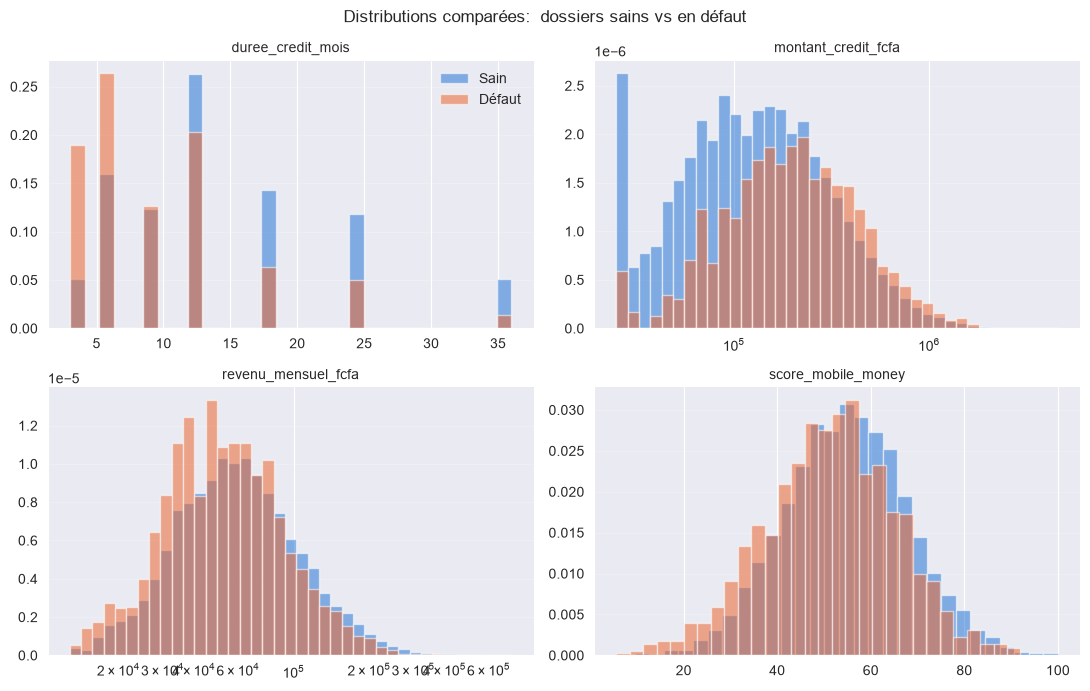

In [93]:
SAIN, DEFAUT = "#2a78d6", "#eb6834"
VARS = ["duree_credit_mois", "montant_credit_fcfa", "revenu_mensuel_fcfa", "score_mobile_money"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), VARS):
    sain, defaut = df.loc[df.defaut_paiement == 0, col].dropna(), df.loc[df.defaut_paiement == 1, col].dropna()
    log = col in ("montant_credit_fcfa", "revenu_mensuel_fcfa")
    bins = np.logspace(np.log10(max(sain.min(), 1)), np.log10(sain.max()), 40) if log else 30
    ax.hist(sain,   bins=bins, density=True, alpha=.55, color=SAIN,   label="Sain")
    ax.hist(defaut, bins=bins, density=True, alpha=.55, color=DEFAUT, label="Défaut")
    if log: ax.set_xscale("log")
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=.2)

axes[0, 0].legend(frameon=False)
fig.suptitle("Distributions comparées:  dossiers sains vs en défaut", fontsize=12)
fig.tight_layout()
plt.savefig("../reports/b2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


# B3. Matrice de corrélation

nb_relances_recouvrement       0.882
duree_credit_mois             -0.203
log_montant_credit_fcfa        0.117
score_mobile_money            -0.094
log_revenu_mensuel_fcfa       -0.093
revenu_mensuel_fcfa           -0.086
nb_retards_anterieurs          0.082
montant_credit_fcfa            0.081
nb_personnes_charge            0.075
membre_groupe_solidaire       -0.074
age                           -0.062
distance_agence_km             0.055
log_distance_agence_km         0.053
log_montant_epargne_fcfa      -0.052
possede_compte_epargne        -0.051
nb_transactions_mm_mois       -0.051
montant_epargne_fcfa          -0.049
taux_interet_annuel            0.048
nb_credits_anterieurs          0.046
anciennete_activite_mois      -0.026
log_charges_mensuelles_fcfa    0.019
annee_octroi                  -0.008
trimestre_octroi               0.008
mois_octroi                    0.007
charges_mensuelles_fcfa        0.004
Name: defaut_paiement, dtype: float64

defaut_paiement,0,1
statut_dossier,,
Contentieux,0.0,1.0
En cours,1.0,0.0
Recouvrement,0.0,1.0
Restructure,0.0,1.0
Solde,1.0,0.0


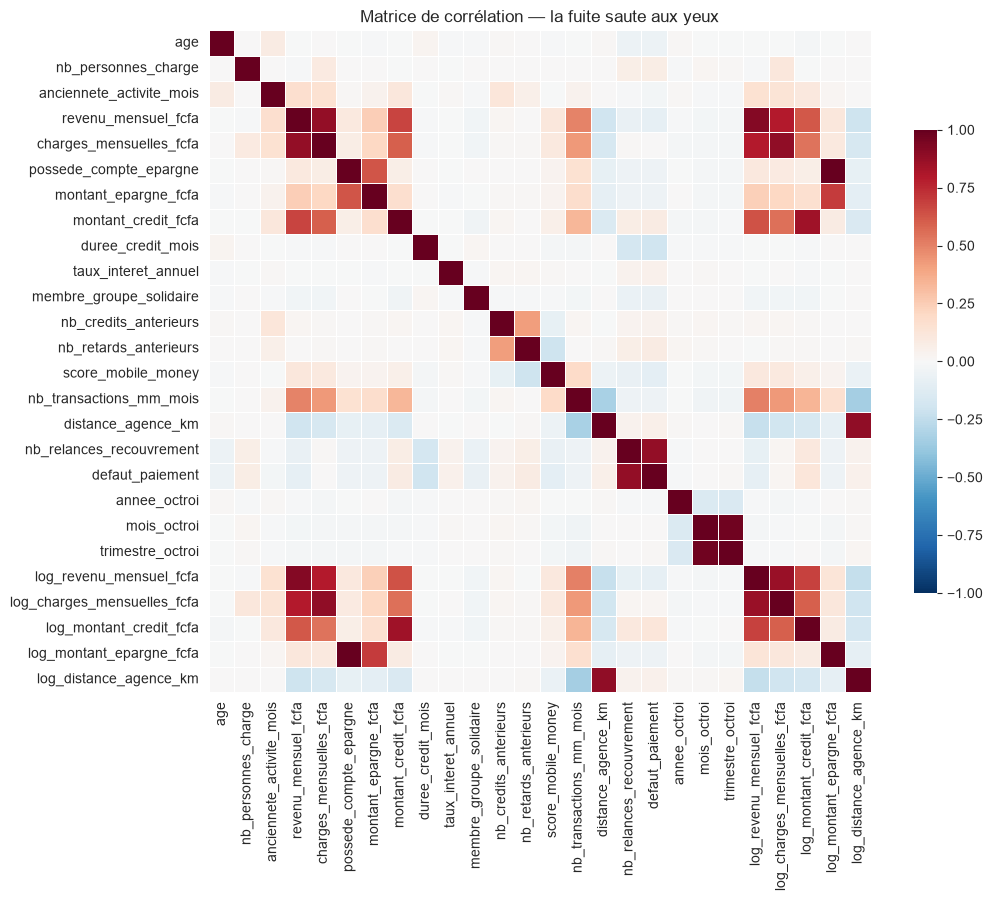

In [94]:
num = df.select_dtypes(include=[np.number])

# 1. Correlation avec la cible
c = num.corr()["defaut_paiement"].drop("defaut_paiement")
display(c.reindex(c.abs().sort_values(ascending=False).index).round(3))

# 2. Heatmap
plt.figure(figsize=(11, 9))
sn.heatmap(num.corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title("Matrice de corrélation — la fuite saute aux yeux")
plt.tight_layout(); plt.savefig("../reports/b3_correlation.png", dpi=150)

# 3. La cible deguisee, en categoriel
display(pd.crosstab(df["statut_dossier"], df["defaut_paiement"], normalize="index").round(3))


# B4. Le score mobile money apporte-t-il de l'information au-delà du revenu ?

In [95]:


print("corr(score_mm, revenu) =", round(df.score_mobile_money.corr(df.revenu_mensuel_fcfa), 3))

pipe = lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                             LogisticRegression(max_iter=1000, class_weight="balanced"))
for nom, cols in [("revenu seul", ["revenu_mensuel_fcfa"]),
                  ("score seul", ["score_mobile_money"]),
                  ("revenu + score", ["revenu_mensuel_fcfa", "score_mobile_money"])]:
    s = cross_val_score(pipe(), df[cols], df.defaut_paiement, cv=5, scoring="roc_auc")
    print(f"{nom:<16} AUC {s.mean():.4f} +/- {s.std():.4f}")

# Croisement quartile de revenu x quartile de score
d = df.dropna(subset=["revenu_mensuel_fcfa", "score_mobile_money"]).copy()
d["qrev"] = pd.qcut(d.revenu_mensuel_fcfa, 4, labels=["Q1", "Q2", "Q3", "Q4"])
d["qmm"]  = pd.qcut(d.score_mobile_money, 4, labels=["Q1", "Q2", "Q3", "Q4"])
display((pd.crosstab(d.qrev, d.qmm, values=d.defaut_paiement, aggfunc="mean") * 100).round(1))


corr(score_mm, revenu) = 0.114
revenu seul      AUC 0.5683 +/- 0.0129
score seul       AUC 0.5627 +/- 0.0091
revenu + score   AUC 0.5910 +/- 0.0094


qmm,Q1,Q2,Q3,Q4
qrev,,,,
Q1,22.3,20.4,20.0,15.6
Q2,19.3,15.7,14.5,13.3
Q3,20.1,14.1,13.7,10.7
Q4,15.6,12.2,8.2,9.5


# B5. Trois graphiques commentés

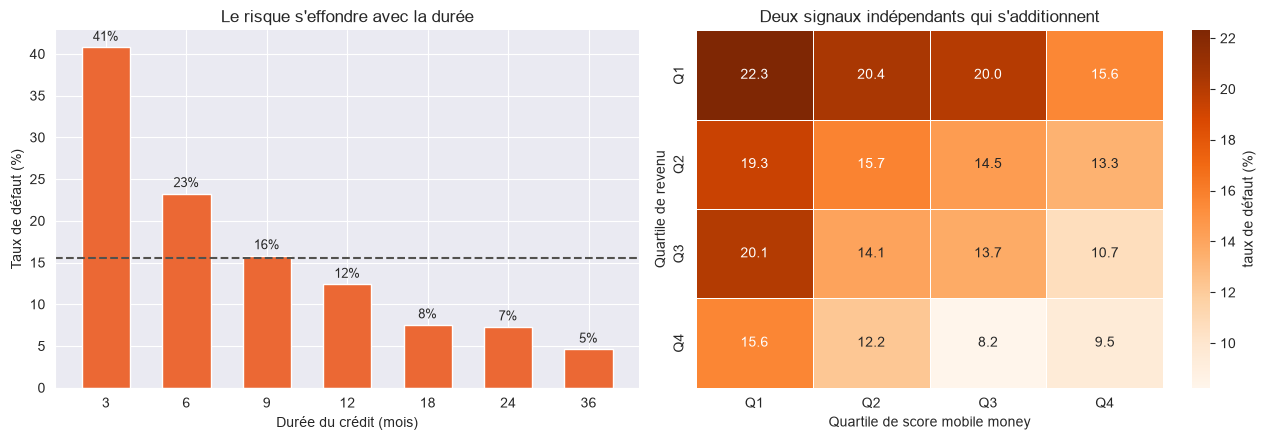

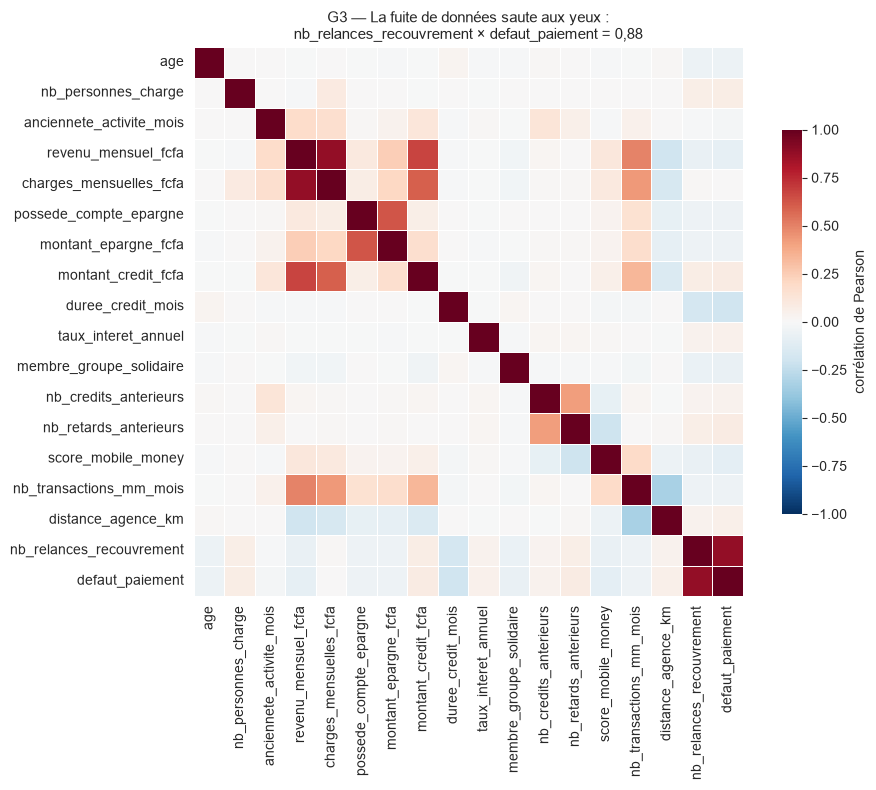

 Les trois phrases d'interprétation : 
 G1 durée. Le taux de défaut passe de 40,8 % à 3 mois à 4,6 % à 36 mois (facteur 9). La relation est monotone décroissante, ce qui explique qu'un modèle linéaire suffise à capter l'essentiel du signal. Attention au sens : la durée courte est un proxy de fragilité (petits crédits d'urgence), pas une cause de défaut.  
 G2  revenu × score. À revenu constant, passer du 1ᵉʳ au 4ᵉ quartile de score mobile money fait chuter le risque de 22,3 % à 15,6 %. Les deux variables sont quasi indépendantes (r = 0,11) et leurs effets s'additionnent : le score apporte bien une information que le revenu déclaré ne contient pas.  
 G3  matrice de corrélation (B3). nb_relances_recouvrement ressort à r = 0,88 quand aucune autre variable ne dépasse 0,20 : c'est une fuite de données, pas un signal. Elle est supprimée avec statut_dossier, dont le croisement montre une correspondance parfaite avec la cible. 


In [96]:
SAIN, DEFAUT = "#2a78d6", "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# G1 : taux de defaut par duree (le signal le plus fort du jeu)
t = df.groupby("duree_credit_mois").defaut_paiement.mean() * 100
axes[0].bar(t.index.astype(str), t.values, color=DEFAUT, width=.6)
axes[0].axhline(df.defaut_paiement.mean() * 100, ls="--", lw=1.5, color="#52514e")
axes[0].set(xlabel="Durée du crédit (mois)", ylabel="Taux de défaut (%)",
            title="Le risque s'effondre avec la durée")
for i, v in enumerate(t.values):
    axes[0].text(i, v + .8, f"{v:.0f}%", ha="center", fontsize=9)

# G2 : revenu x score mobile money
piv = pd.crosstab(d.qrev, d.qmm, values=d.defaut_paiement, aggfunc="mean") * 100
sn.heatmap(piv, annot=True, fmt=".1f", cmap="Oranges", ax=axes[1],
            cbar_kws={"label": "taux de défaut (%)"}, linewidths=.5)
axes[1].set(xlabel="Quartile de score mobile money", ylabel="Quartile de revenu",
            title="Deux signaux indépendants qui s'additionnent")

for ax in axes: ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.savefig("../reports/b5_graphiques.png", dpi=150, bbox_inches="tight")


# G3 : matrice de correlation AVANT suppression des colonnes de fuite
brut = pd.read_csv("../data/credits_microfinance.csv").drop_duplicates()
brut["revenu_mensuel_fcfa"] = brut["revenu_mensuel_fcfa"].replace(-999, np.nan)
brut.loc[brut.revenu_mensuel_fcfa > 2e6, "revenu_mensuel_fcfa"] /= 1000
brut["age"] = brut["age"].replace(-1, np.nan)
brut["distance_agence_km"] = brut["distance_agence_km"].replace(9999, np.nan)

corr = brut.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sn.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={"shrink": .7, "label": "corrélation de Pearson"}, ax=ax)
ax.set_title("G3 — La fuite de données saute aux yeux :\n"
             "nb_relances_recouvrement × defaut_paiement = 0,88", fontsize=11)
fig.tight_layout()
fig.savefig("../reports/g3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


print(" Les trois phrases d'interprétation : \n "
      "G1 durée. Le taux de défaut passe de 40,8 % à 3 mois à 4,6 % à 36 mois (facteur 9). La relation est monotone décroissante, ce qui explique qu'un modèle linéaire suffise à capter l'essentiel du signal. Attention au sens : la durée courte est un proxy de fragilité (petits crédits d'urgence), pas une cause de défaut.  \n "
      "G2  revenu × score. À revenu constant, passer du 1ᵉʳ au 4ᵉ quartile de score mobile money fait chuter le risque de 22,3 % à 15,6 %. Les deux variables sont quasi indépendantes (r = 0,11) et leurs effets s'additionnent : le score apporte bien une information que le revenu déclaré ne contient pas.  \n "
      "G3  matrice de corrélation (B3). nb_relances_recouvrement ressort à r = 0,88 quand aucune autre variable ne dépasse 0,20 : c'est une fuite de données, pas un signal. Elle est supprimée avec statut_dossier, dont le croisement montre une correspondance parfaite avec la cible. ")

# Partie C  Ingénierie de variables

In [97]:

df = preparer(pd.read_csv("../data/credits_microfinance.csv"))
print(df.shape)

# Pouvoir discriminant univarie de chaque variable derivee
DERIVEES = ["ratio_endettement", "log_ratio_endettement", "credit_sur_revenu",
            "mensualite_estimee", "ratio_charges", "agri_credit_court",
            "taux_retard_historique", "primo_emprunteur", "couverture_epargne",
            "capacite_remboursement", "revenu_par_personne", "epargne_sur_credit",
            "score_mm_manquant", "revenu_manquant"]
for c in DERIVEES:
    m = df[c].notna()
    print(f"{c:<26} AUC {roc_auc_score(df.defaut_paiement[m], df[c][m]):.3f}")


(9200, 43)
ratio_endettement          AUC 0.825
log_ratio_endettement      AUC 0.825
credit_sur_revenu          AUC 0.706
mensualite_estimee         AUC 0.682
ratio_charges              AUC 0.659
agri_credit_court          AUC 0.548
taux_retard_historique     AUC 0.540
primo_emprunteur           AUC 0.484
couverture_epargne         AUC 0.443
capacite_remboursement     AUC 0.354
revenu_par_personne        AUC 0.408
epargne_sur_credit         AUC 0.453
score_mm_manquant          AUC 0.508
revenu_manquant            AUC 0.497


# Partie D  Modélisation

# D1. Séparation temporelle

In [98]:


df = preparer(pd.read_csv("../data/credits_microfinance.csv"))

EXCLURE = ["defaut_paiement",      # la cible
           "id_client",            # identifiant, aucun pouvoir predictif
           "date_octroi",          # sert a la decoupe, pas au modele
           "annee_octroi",         # 2025 absente du train : extrapolation (cf. A5)
           "periode_octroi",
           "agent_credit"]         # 26 modalites, risque de proxy discriminant

COLS_NUM = [c for c in df.select_dtypes(include=[np.number]).columns if c not in EXCLURE]
COLS_CAT = [c for c in df.select_dtypes(include="object").columns if c not in EXCLURE]

X, y = df[COLS_NUM + COLS_CAT], df["defaut_paiement"]
print(f"{len(COLS_NUM)} numeriques + {len(COLS_CAT)} categorielles = {X.shape[1]} variables")


32 numeriques + 7 categorielles = 39 variables


In [99]:
seuil = df["date_octroi"].quantile(0.8)
train = df["date_octroi"] <  seuil
test  = df["date_octroi"] >= seuil

X_train, y_train = X[train], y[train]
X_test,  y_test  = X[test],  y[test]

print(f"Seuil : {seuil.date()}")
print(f"train : {train.sum():>5} ({train.mean()*100:.1f} %)  "
      f"{df.loc[train,'date_octroi'].min().date()} -> {df.loc[train,'date_octroi'].max().date()}")
print(f"test  : {test.sum():>5} ({test.mean()*100:.1f} %)  "
      f"{df.loc[test,'date_octroi'].min().date()} -> {df.loc[test,'date_octroi'].max().date()}")
print(f"defaut : train {y_train.mean()*100:.1f} % | test {y_test.mean()*100:.1f} %")
print(f"dates presentes des deux cotes : "
      f"{len(set(df.loc[train,'date_octroi']) & set(df.loc[test,'date_octroi']))}")


Seuil : 2024-05-29
train :  7352 (79.9 %)  2021-01-01 -> 2024-05-28
test  :  1848 (20.1 %)  2024-05-29 -> 2025-03-30
defaut : train 15.5 % | test 15.5 %
dates presentes des deux cotes : 0


# D2. Le pipeline

In [100]:
def prepro():
    return ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), COLS_NUM),
        ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                              OneHotEncoder(handle_unknown="ignore")), COLS_CAT),
    ])


# D3/D4. Trois familles + validation croisée

In [106]:
CV = StratifiedKFold(5, shuffle=True, random_state=42)

def evaluer(nom, pipe):
    s = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="roc_auc")
    pipe.fit(X_train, y_train)
    test = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    print(f"{nom:<32} CV {s.mean():.4f} +/- {s.std():.4f}   test {test:.4f}")
    return {"modele": nom, "cv": round(s.mean(),4), "ecart_type": round(s.std(),4), "test": round(test,4)}

resultats = [
    evaluer("Regression logistique", Pipeline([("pre", prepro()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])),
    evaluer("Foret aleatoire", Pipeline([("pre", prepro()),
        ("clf", RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                       class_weight="balanced", random_state=42, n_jobs=-1))])),
    evaluer("HistGradientBoosting", Pipeline([("pre", prepro()),
        ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=42))])),
    evaluer("XGBoost ", Pipeline([("pre", prepro()),
        ("clf", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
              eval_metric="logloss", random_state=42, n_jobs=-1))])),
]


Regression logistique            CV 0.8491 +/- 0.0128   test 0.8331
Foret aleatoire                  CV 0.8456 +/- 0.0135   test 0.8144
HistGradientBoosting             CV 0.8375 +/- 0.0163   test 0.8103
XGBoost                          CV 0.8373 +/- 0.0173   test 0.8115


# D5. Déséquilibre, 4 approches à modèle égal

In [107]:

LOG = lambda **kw: LogisticRegression(max_iter=2000, random_state=42, **kw)
evaluer("1. aucun traitement", Pipeline([("pre", prepro()), ("clf", LOG())]))
evaluer("2. class_weight='balanced'", Pipeline([("pre", prepro()), ("clf", LOG(class_weight="balanced"))]))
evaluer("3. sous-echantillonnage", ImbPipeline([("pre", prepro()),
        ("sampler", RandomUnderSampler(random_state=42)), ("clf", LOG())]))
evaluer("4. SMOTE", ImbPipeline([("pre", prepro()), ("sampler", SMOTE(random_state=42)), ("clf", LOG())]))


1. aucun traitement              CV 0.8484 +/- 0.0126   test 0.8323
2. class_weight='balanced'       CV 0.8491 +/- 0.0128   test 0.8331
3. sous-echantillonnage          CV 0.8446 +/- 0.0112   test 0.8309
4. SMOTE                         CV 0.8465 +/- 0.0130   test 0.8286


{'modele': '4. SMOTE',
 'cv': np.float64(0.8465),
 'ecart_type': np.float64(0.013),
 'test': 0.8286}

# D6. Réglage des hyperparamètres

In [110]:

grille = {
    "clf__C":            np.logspace(-3, 2, 20),
    "clf__l1_ratio":     [0, 0.5, 1],
    "clf__class_weight": ["balanced", None],
}

recherche = RandomizedSearchCV(
    Pipeline([("pre", prepro()),
              ("clf", LogisticRegression(solver="saga", max_iter=3000, random_state=42))]),
    grille, n_iter=30, cv=CV, scoring="roc_auc", random_state=42, refit=True)
recherche.fit(X_train, y_train)

print(recherche.best_params_)
print(f"CV {recherche.best_score_:.4f} | test {roc_auc_score(y_test, recherche.predict_proba(X_test)[:,1]):.4f}")


{'clf__l1_ratio': 0, 'clf__class_weight': 'balanced', 'clf__C': np.float64(0.06951927961775606)}
CV 0.8497 | test 0.8322
